# M4-B2 — Vision PCB Defect (binôme async)

Auteurs : `<prénom1>` × `<prénom2>` — Date : `<date>`

**Conventions** :
- `random_state=42`
- Pas de `print` excessif
- `Co-authored-by:` sur les commits significatifs

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.append('..')  # racine du repo → permet les imports « package » src.*
from src.load_data import CLASSES, get_dataloaders

DATA_DIR = Path('../data/pcb_defect_sample')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

Device : cpu


## 1. EDA dataset PCB (~1h binôme)

- Distribution des 7 classes (déséquilibre ?)
- Visualisation 7×3 subplot (3 exemples par classe)
- Notes : qualité d'image, variabilité intra-classe, ambiguïtés

In [2]:
# TODO — distribution des classes
from collections import Counter
counts = Counter(DATA_DIR.glob('*.png'))
for cls in CLASSES:
    cls_count = len(list(DATA_DIR.glob(f'{cls}/*.png')))
    print(f"Classe {cls}: {cls_count} images")

Classe ok: 300 images
Classe open: 300 images
Classe short: 300 images
Classe mousebite: 300 images
Classe spur: 300 images
Classe copper: 300 images
Classe pin_hole: 300 images


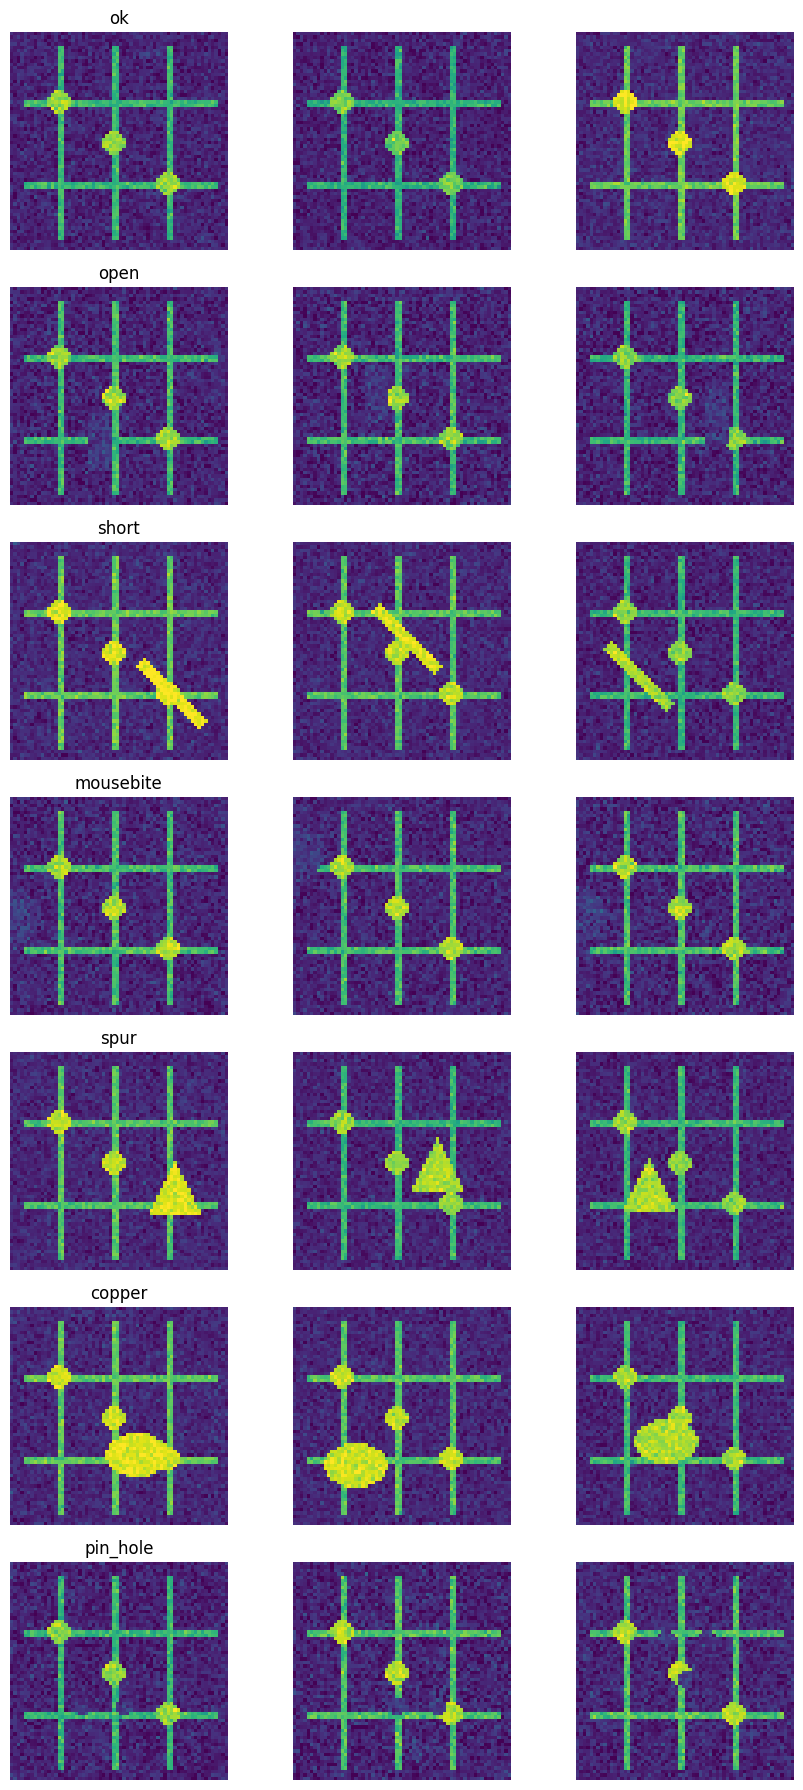

In [3]:
# TODO — 3 exemples par classe en grille 7×3
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(len(CLASSES), 3, figsize=(9, 18))

for i, cls in enumerate(CLASSES):
    images = list((DATA_DIR / cls).glob("*.png"))[:3]

    for j, img_path in enumerate(images):
        img = Image.open(img_path)

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if j == 0:
            axes[i, j].set_title(cls)

plt.tight_layout()
plt.show()

## 2. Implémentation de l'option choisie (~4h binôme)

Cf. `decisions.md` pour le choix (A / B / C).

- Option A : `src/option_a_cnn.py`
- Option B : `src/option_b_transfer.py`
- Option C : `src/option_c_clip.py`

In [ ]:
# TODO — entraîner ou inférer l'option choisie
# Import : from src.option_a_cnn import SimpleCNN, train_one_epoch, evaluate  (idem b/c)
# Mesure : temps train (si options A ou B), latence inférence (toutes options), accuracy
from src.option_b_transfer import SimpleTransferModel, train_one_epoch, evaluate
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from src.load_data import PCBDefectDataset
from src.option_b_transfer import get_transfer_transforms

transfer_transform = get_transfer_transforms()

dataset = PCBDefectDataset(
    DATA_DIR,
    transform=transfer_transform
)

n_total = len(dataset)
n_val = int(n_total * 0.15)
n_test = int(n_total * 0.15)
n_train = n_total - n_val - n_test

generator = torch.Generator().manual_seed(42)

train_ds, val_ds, test_ds = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=generator
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleTransferModel().to(device)

for param in model.layer4.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

epochs = 5

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.2%} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.2%}"
    )

test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2%}")

Epoch 1/5 | Train loss: 1.2079 | Train acc: 55.37% | Val loss: 0.8842 | Val acc: 61.59%
Epoch 2/5 | Train loss: 0.3966 | Train acc: 92.38% | Val loss: 0.6101 | Val acc: 75.87%
Epoch 3/5 | Train loss: 0.1259 | Train acc: 99.12% | Val loss: 0.5831 | Val acc: 75.24%


## 2bis. Implémentation de l'option A (CNN from scratch), pour comparaison

In [ ]:
# Option A — CNN from scratch : entraînement + inférence
import time

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from src.option_a_cnn import SimpleCNN, evaluate, train_one_epoch

torch.manual_seed(42)

train_loader, val_loader, test_loader = get_dataloaders(DATA_DIR, batch_size=32, seed=42)

model = SimpleCNN(n_classes=len(CLASSES)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 8
history = []

train_start = time.perf_counter()
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    history.append((epoch, train_loss, train_acc, val_loss, val_acc))
    print(f"Epoch {epoch}: train_loss {train_loss:.3f}, train_acc {train_acc:.3f} | val_loss {val_loss:.3f}, val_acc {val_acc:.3f}")
train_time_s = time.perf_counter() - train_start

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"\nTemps d'entraînement ({EPOCHS} epochs) : {train_time_s:.1f} s")
print(f"Accuracy train (dernière epoch) : {history[-1][2]:.3f}")
print(f"Accuracy val (dernière epoch)   : {history[-1][4]:.3f}")
print(f"Accuracy test                   : {test_acc:.3f}")

In [ ]:
# Latence d'inférence (batch=1, moyenne sur le test set) + persistance du modèle
model.eval()
single_loader = DataLoader(test_loader.dataset, batch_size=1, shuffle=False)

latencies_ms = []
with torch.no_grad():
    for X, _ in single_loader:
        X = X.to(DEVICE)
        t0 = time.perf_counter()
        model(X)
        latencies_ms.append((time.perf_counter() - t0) * 1000)

mean_latency_ms = sum(latencies_ms) / len(latencies_ms)
print(f"Latence d'inférence moyenne : {mean_latency_ms:.2f} ms/image")

MODEL_PATH = Path('../models/option_a_cnn.pt')
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Modèle sauvegardé : {MODEL_PATH}")

## 3. Comparaison économique 3 approches (~1h30)

Voir `economic_comparison.md` à remplir.

## 4. Verdict + préparation restitution duo (~1h30)

- `verdict.md` : recommandation, 8 lignes max
- Préparation restitution mardi 1ᵉʳ sept (rentrée M5) : qui dit quoi ?